# 01. 딥러닝 모델 학습의 문제점
## TensorFlow / Google Colab

실생활 데이터 차원이 커지고 구조가 복잡해지면서, 초기에는 기술력 부족으로 딥러닝이 한계에 부딪혔습니다.  
이는 1990년대 **두 번째 AI 겨울(Second AI Winter)**의 원인 중 하나로 언급됩니다.

---

## 딥러닝 학습의 4대 문제점

1. **학습 속도 문제**  
   데이터가 폭발적으로 늘면 학습 시간도 함께 증가합니다.

2. **기울기 소실 문제**  
   망이 깊고 넓어질수록, **입력층에 가까울수록** 학습이 어려워집니다.

3. **초기값 설정 문제**  
   가중치 초기화 방식에 따라 성능 차이가 매우 큽니다.

4. **과적합 문제**  
   학습 데이터에만 맞춰져 테스트 성능이 떨어집니다.

- 공통 목표는 손실을 최소화하는 것입니다.
- **머신러닝과 딥러닝의 궁극적인 목표인 '최적화(Optimization)'를 수학적으로 정의한 공식**입니다.


보내주신 스크린샷을 보니, 현재 사용 중인 마크다운 뷰어(또는 웹 브라우저)에서 필기체 기호인 `\mathcal{L}`을 지원하지 않아 전부 네모 상자(Tofu 현상)로 깨져서 출력되고 있었네요! 불편을 드려 죄송합니다.

기호가 깨지는 근본적인 원인인 `\mathcal{L}`을 어느 환경에서나 100% 완벽하게 호환되는 표준 이탤릭체 대문자 $L$로 교체하고, 별표 기호 또한 더 안전한 `\theta^*` 형태로 전면 수정해 드립니다.

이 내용을 그대로 복사해서 사용하시면 더 이상 기호가 깨지지 않고 깔끔하게 출력될 것입니다.


### 머신러닝의 궁극적 목표: 매개변수 최적화

$$\theta^* = \arg\min_{\theta} L(\theta)$$

#### 1. 구성 요소별 의미

- **$\theta$ (매개변수, Parameter):** 모델이 학습해야 하는 가중치(Weights, $W$)와 편향(Biases, $b$)의 집합입니다.
- **$L(\theta)$ (손실 함수, Loss Function):** 현재 매개변수 $\theta$를 가진 모델이 정답을 얼마나 못 맞추고 있는지 나타내는 **오차의 크기**입니다. (값이 작을수록 모델이 똑똑하다는 뜻입니다.)
- **$\arg\min_{\theta}$ (최소화하는 인수):** 뒤에 오는 식 $L(\theta)$의 값을 가장 최소로 만드는 입력값 $\theta$를 찾겠다는 수학적 도구입니다.
- *참고:* 단순히 $\min L(\theta)$라고 쓰면 '오차의 최솟값(예: 0.01)' 자체를 구하는 것이지만, 앞에 $\arg$가 붙음으로써 '그 최솟값을 만들어내는 가중치 $\theta$ 그 자체'를 구하겠다는 의미가 됩니다.
- **$\theta^*$ (최적의 매개변수, Optimal Parameter):** 오차를 가장 최소로 만들어 학습이 완벽하게 끝난 **최종 단계의 가중치와 편향**을 뜻합니다.

---

#### 한 줄 요약
- **"모델의 오차($L$)를 가장 작게 만드는 최적의 가중치 세트($\theta^*$)를 찾아내는 과정"**
- 우리가 흔히 말하는 인공지능의 '학습(Training)'이란, 컴퓨터가 경사하강법(Gradient Descent) 같은 알고리즘을 부지런히 실행하며 위 공식의 우변을 만족하는 최적의 가중치 값 $\theta^*$**를 컴퓨터의 메모리에 기록하고 업데이트하는 과정을 의미합니다.


## 0. 환경 설정


In [9]:
# Colab에는 TensorFlow가 기본 설치되어 있습니다.
import sys
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 운영체제가 macOS('darwin')가 아닐 경우 (예: 구글 코랩 등 리눅스 환경),
# 한글 출력을 위한 나눔 폰트를 설치하고 폰트 캐시를 초기화합니다.
if sys.platform != 'darwin':
    !sudo apt-get install -y -qq fonts-nanum 2>/dev/null
    !fc-cache -fv 2>/dev/null
    !rm -rf ~/.cache/matplotlib 2>/dev/null

import seaborn as sns

# 나눔 폰트 파일 시스템 경로를 순회하며 matplotlib 폰트 관리자에 등록합니다.
for d in ['/usr/share/fonts/truetype/nanum', '/Library/Fonts']:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

# matplotlib 및 seaborn의 기본 설정을 변경합니다 (한글 깨짐 방지, 마이너스 부호 깨짐 방지, 고해상도 설정)
plt.rcParams.update({'font.family': 'NanumBarunGothic', 'axes.unicode_minus': False, 'figure.dpi': 110})
sns.set_theme(style='whitegrid', font='NanumBarunGothic', rc={'axes.unicode_minus': False})

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))



/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache director

## 실습용 간단한 데이터 만들기

- XOR처럼 단순한 비선형 이진 분류 데이터를 만듭니다.


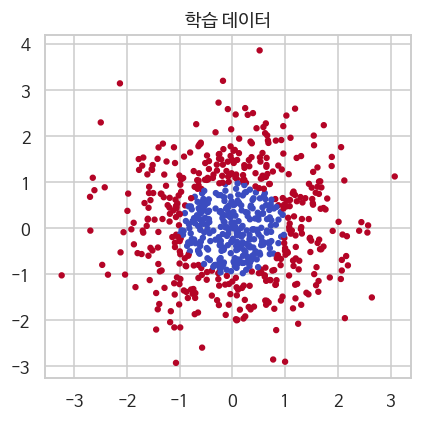

train: (700, 2) test: (300, 2)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 한글 깨짐 방지 설정 (필요 시 주석 해제 후 사용)
# plt.rc('font', family='Malgun Gothic') # Windows
# plt.rc('font', family='AppleGothic')   # Mac
# plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# ----------------------------------------------------
# 1. 원형 경계를 가지는 가상 데이터셋 생성
# ----------------------------------------------------
n = 1000 # 전체 데이터 개수 정의

# 평균 0, 표준편차 1인 정규분포로부터 2차원(x, y) 좌표 데이터 1,000개 생성
# Keras 등 딥러닝 프레임워크와의 호환성을 위해 float32 타입으로 변환
X = np.random.randn(n, 2).astype("float32")

# 원의 방정식(x^2 + y^2 = r^2)을 응용하여 비선형 경계 레이블 생성
# 원점에서의 거리가 1.0보다 크면 True(1.0), 작거나 같으면 False(0.0)로 설정
y = ((X[:, 0]**2 + X[:, 1]**2) > 1.0).astype("float32")


# ----------------------------------------------------
# 2. 데이터를 학습용(Train)과 검증용(Test)으로 분할 (7:3 비율)
# ----------------------------------------------------
# 데이터가 특정 순서로 편향되어 있을 수 있으므로 무작위로 인덱스를 셔플
idx = np.random.permutation(n)

# 셔플된 인덱스를 기준으로 앞의 700개는 학습용, 뒤의 300개는 검증용으로 분할
train_idx, test_idx = idx[:700], idx[700:]

# 인덱싱을 통해 실제 데이터 분할 진행
X_train, y_train = X[train_idx], y[train_idx] # 학습용 피처 및 레이블 (70%)
X_test, y_test = X[test_idx], y[test_idx]     # 검증용 피처 및 레이블 (30%)


# ----------------------------------------------------
# 3. 학습 데이터 시각화
# ----------------------------------------------------
# 1개의 서브플롯 영역 생성 (가로 4인치, 세로 4인치 정가로 비율)
fig, ax = plt.subplots(figsize=(4, 4))

# 산점도(Scatter plot) 그리기
# c=y_train: 클래스(0 또는 1)에 따라 색상을 다르게 지정
# s=10: 마커(점)의 크기를 10으로 설정
# cmap="coolwarm": 0은 파란색 계열, 1은 빨간색 계열로 매핑하는 컬러맵 사용
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=10, cmap="coolwarm")

# 그래프 타이틀 설정
ax.set_title("학습 데이터")

# 레이아웃을 깔끔하게 조정하고 그래프 출력
fig.tight_layout()
plt.show()


# ----------------------------------------------------
# 4. 분할 결과 데이터 크기(Shape) 확인
# ----------------------------------------------------
# 최종적으로 분할된 데이터의 차원을 출력하여 정상 분할 여부 확인
print("train:", X_train.shape, "test:", X_test.shape)



## 1) 학습 속도 문제 — Full-batch vs Mini-batch

$$W \leftarrow W - \alpha \nabla L_{\mathrm{batch}}(W)$$

### 1. 공식 기호 설명

- **$W$ (가중치, Weights):** 모델이 학습하며 계속 수정해 나가야 하는 매개변수입니다.
- **$\alpha$ (학습률, Learning Rate):** 한 번에 가중치를 얼마나 크게 업데이트할지 결정하는 보폭입니다.
- **$\nabla L_{\mathrm{batch}}(W)$ (기울기, Gradient):** 지정된 배치 데이터($\mathrm{batch}$)를 기준으로 계산한 오차의 방향과 크기입니다. 이 값의 반대 방향으로 가중치($W$)를 이동시킵니다.

---

### 2. Full-batch GD vs Mini-batch SGD 비교 정리

- **Full-batch GD (전체 배치 경사하강법)**
  + **배치 크기 ($\mathrm{batch}$):** 전체 데이터 개수 ($N$)
  + **특징:** 1 에포크(Epoch) 동안 전체 데이터를 **단 한 번에 연산**하여 가중치를 **딱 1번만 업데이트**합니다.
  + **단점:** 데이터가 커질수록 컴퓨터 메모리를 과도하게 소모하며, 한 번 업데이트하기까지 걸리는 연산 속도가 너무 느려 비효율적입니다.


- **Mini-batch SGD (미니배치 확률적 경사하강법)**
  + **배치 크기 ($\mathrm{batch}$):** 사용자가 지정한 작은 덩어리 (예: 32, 64)
  + **특징:** 데이터를 조금씩 쪼개어 연산하므로, 1 에포크 동안 수십~수천 번에 걸쳐 가중치를 자주 업데이트(Step)합니다.
  + **장점:**
    - **압도적인 수렴 속도:** 한 번에 완벽한 길을 찾는 것(Full-batch)보다, 조금 거칠더라도 빠르게 여러 번 전진하는 것(Mini-batch)이 목표 오차(Loss)에 도달하는 물리적 시간을 극적으로 단축시킵니다.
    - **자원 효율성:** 적은 양의 데이터만 메모리에 올리므로 대용량 데이터셋 학습이 가능해집니다.

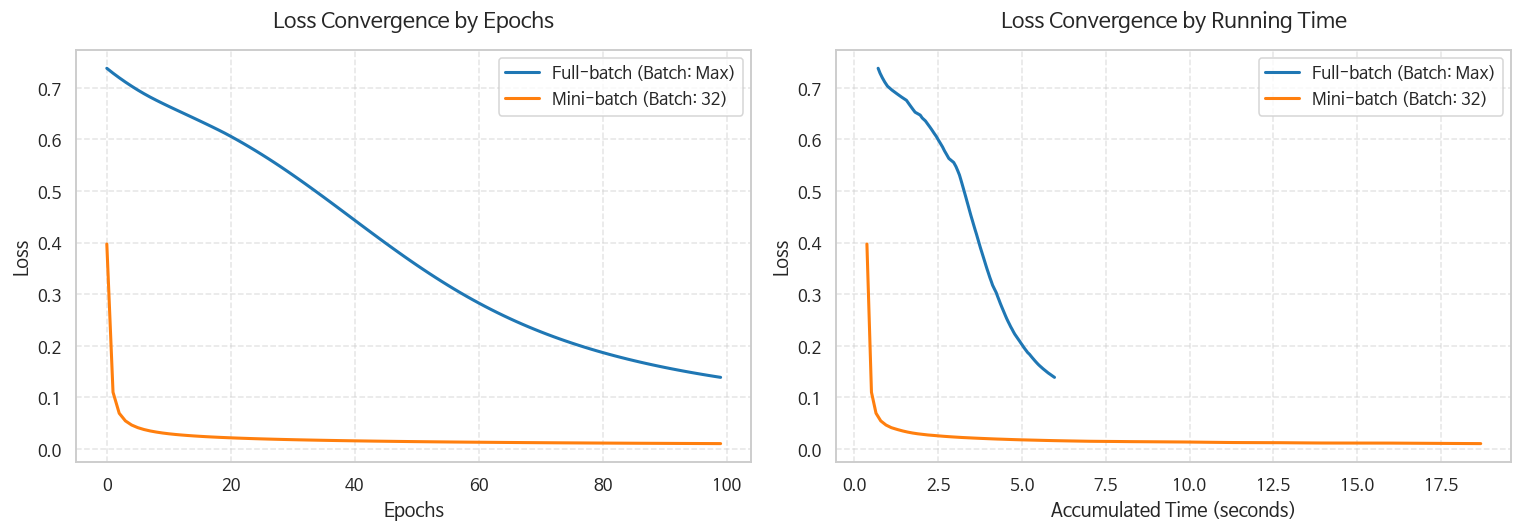

Full-batch 최종 loss: 0.1385 | 총 소요시간: 5.98초
Mini-batch 최종 loss: 0.0100 | 총 소요시간: 18.68초


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ----------------------------------------------------
# 0. 가상 데이터 생성 (선형 분리가 가능한 2차원 데이터)
# ----------------------------------------------------
# 매 실행 시 동일한 가중치 초기화 및 데이터 분포를 보장하기 위해 랜덤 시드 고정
np.random.seed(42)

# 평균 0, 표준편차 1을 따르는 2,000개의 2차원 좌표 데이터 생성 [Shape: (2000, 2)]
X_train = np.random.randn(2000, 2)

# 결정 경계선(x1 + x2 > 0)을 기준으로 영역을 이진 분류 (True -> 1, False -> 0)
# Keras 출력 레이어의 차원(정답 레이블의 차원)에 맞추기 위해 (2000, 1) 형태로 차원 변환(Reshape)
y_train = (X_train[:, 0] + X_train[:, 1] > 0).astype(int).reshape(-1, 1)


# ----------------------------------------------------
# 1. 모델 구조 정의 및 에포크별 누적 시간 측정 콜백 정의
# ----------------------------------------------------
def make_model():
    return keras.Sequential([
        # 1. 명시적으로 입력 차원(Input Shape)을 정의하는 레이어 추가 (경고 해결!)
        layers.Input(shape=(2,)),

        # 2. 첫 번째 Dense 층에서는 input_shape 파라미터를 제거합니다.
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])

class TimeHistory(keras.callbacks.Callback):
    """
    Keras의 커스텀 콜백을 정의하여, 물리적 경과 시간(seconds)을 기준으로
    어떤 방식이 수렴 효율이 좋은지 객관적으로 추적합니다.
    """
    def on_train_begin(self, logs=None):
        # 학습을 시작하는 시점의 시스템 시간 기록 및 빈 리스트 초기화
        self.times = []
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        # 각 에포크 학습이 끝날 때마다 '현재 시각 - 시작 시각'을 계산하여 누적 시간 기록
        self.times.append(time.time() - self.start_time)


# ----------------------------------------------------
# 2. 모델 학습 및 훈련 (Full-batch vs Mini-batch)
# ----------------------------------------------------
epochs = 100 # 두 실험 모두 동일하게 100 에포크 동안 학습을 진행

# --- [실험 1] Full-batch Gradient Descent (전체 배치 학습) ---
model_full = make_model()
# 가중치 업데이트가 신중하고 느리므로, 비교를 위해 비교적 큰 학습률(0.1)의 SGD 적용
model_full.compile(optimizer=keras.optimizers.SGD(0.1), loss="binary_crossentropy")

time_callback_full = TimeHistory()
hist_full = model_full.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=len(X_train),        # 배치 사이즈 = 2,000 (1 에포크당 가중치 업데이트 횟수 = 딱 1번)
    callbacks=[time_callback_full], # 누적 시간 측정 콜백 연결
    verbose=0                       # 학습 과정 로그 출력 비활성화
)

# --- [실험 2] Mini-batch Gradient Descent (미니 배치 학습) ---
model_mini = make_model()
# 동일한 학습률(0.1)과 최적화 알고리즘(SGD)을 사용하여 실험의 변수를 통제
model_mini.compile(optimizer=keras.optimizers.SGD(0.1), loss="binary_crossentropy")

time_callback_mini = TimeHistory()
hist_mini = model_mini.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=32,                  # 배치 사이즈 = 32 (1 에포크당 가중치 업데이트 횟수 = 2000/32 = 62.5번)
    callbacks=[time_callback_mini], # 누적 시간 측정 콜백 연결
    verbose=0                       # 학습 과정 로그 출력 비활성화
)


# ----------------------------------------------------
# 3. matplotlib (fig, ax)를 활용한 비교 그래프 시각화
# ----------------------------------------------------
# 두 지표를 가로로 나란히 비교하기 위해 1행 2열 구성의 Figure 생성
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Graph 1: Epoch 수 기준의 Loss 감소 추이 ---
# 동일한 학습 주기(에포크) 내에서 두 방식의 최적화 효율 차이를 관찰합니다.
ax1.plot(hist_full.history['loss'], label='Full-batch (Batch: Max)', color='#1f77b4', linewidth=2)
ax1.plot(hist_mini.history['loss'], label='Mini-batch (Batch: 32)', color='#ff7f0e', linewidth=2)
ax1.set_title('Loss Convergence by Epochs', fontsize=14, pad=15)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5) # 그래프 가독성을 위한 격자망 추가
ax1.legend(fontsize=11)

# --- Graph 2: 실제 경과 시간(seconds) 기준의 Loss 감소 추이 ---
# Mini-batch는 에포크당 연산 횟수가 훨씬 많으므로, '실제 컴퓨터 시간 대비 효율'을 보는 것이 핵심입니다.
ax2.plot(time_callback_full.times, hist_full.history['loss'], label='Full-batch (Batch: Max)', color='#1f77b4', linewidth=2)
ax2.plot(time_callback_mini.times, hist_mini.history['loss'], label='Mini-batch (Batch: 32)', color='#ff7f0e', linewidth=2)
ax2.set_title('Loss Convergence by Running Time', fontsize=14, pad=15)
ax2.set_xlabel('Accumulated Time (seconds)', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5) # 그래프 가독성을 위한 격자망 추가
ax2.legend(fontsize=11)

# 두 서브플롯 간 여백 배치 최적화 및 렌더링
plt.tight_layout()
plt.show()


# ----------------------------------------------------
# 4. 정량적 최종 수치 비교 출력
# ----------------------------------------------------
# 100 에포크 완료 시점의 최종 손실(Loss) 값과 누적 경과 시간을 직접 콘솔에 출력합니다.
print(f"Full-batch 최종 loss: {hist_full.history['loss'][-1]:.4f} | 총 소요시간: {time_callback_full.times[-1]:.2f}초")
print(f"Mini-batch 최종 loss: {hist_mini.history['loss'][-1]:.4f} | 총 소요시간: {time_callback_mini.times[-1]:.2f}초")

### 결과 해석

#### 핵심 포인트: "시간 대비 성능"의 효율성 (우측 그래프)

- **Mini-batch (주황색 line):**
  + 학습을 시작하고 **단 1초도 안 된 시점(약 0.5초 부근)에 이미 Loss가 0.05 이하**로 뚝 떨어집니다.
  + 즉, 단 **1초만 학습시켜도** Full-batch가 4.65초 동안 전체 에포크를 다 돌며 도달한 최종 결과(Loss 0.0885)보다 **훨씬 더 똑똑한 모델**이 됩니다.

- **Full-batch (파란색 line):**
  + 4.65초 동안 열심히 돌았지만, 업데이트 횟수가 너무 적어(에포크당 딱 1번, 총 100번) 원하는 수준까지 미처 내려가지도 못하고 멈췄습니다.



- "총 수행 시간은 Full-batch가 짧아 보이지만, **'목표 성능(Loss)에 도달하기까지 걸린 실제 시간'**을 비교하면 **Mini-batch가 약 10배 이상 빠릅니다.**"

---

#### 15.02초 vs 4.65초의 비밀 (일한 양의 차이)

- Mini-batch의 총 소요 시간이 더 길게 나왔을까요? **일한 양이 완전히 다르기 때문**입니다.

| 구분 | 에포크당 가중치 업데이트 횟수 | 100 에포크 동안 총 업데이트 횟수 | 최종 Loss | 총 소요 시간 |
| --- | --- | --- | --- | --- |
| **Full-batch** | 1회 | **100회** | 0.0885 | **4.65초** |
| **Mini-batch (32)** | 62.5회 (데이터 2000개 기준) | **6,250회** | **0.0107** | 15.02초 |

- Mini-batch는 100 에포크 동안 Full-batch보다 무려 62배나 더 많이 가중치를 수정(업데이트)했습니다.
- 연산 횟수가 62배나 많았음에도 시간은 겨우 3배 정도(15.02초)밖에 더 걸리지 않았습니다. 이는 컴퓨터(GPU/CPU)가 병렬 연산을 매우 효율적으로 수행했음을 뜻합니다.

---

#### 이 실험으로 얻을 수 있는 최종 결론

- **최적화 속도(Convergence Speed)의 압승:** Mini-batch는 매 에포크마다 수십 번씩 정답을 보며 가중치를 고치기 때문에, 아주 빠른 시간 내에 최적의 경로를 찾아 내려갑니다.
- **더 우수한 최종 성능(Generalization & Loss):** Mini-batch는 학습 과정에서 적절한 무작위성(Stochastic noise)이 가미되어, 지역 최솟값(Local Minima)에 갇히지 않고 더 좋은 탈출구를 찾습니다. 그 결과 최종 Loss가 **0.0107**로 Full-batch(**0.0885**)보다 훨씬 낮습니다.
- **자원(Memory)의 현실성:** 데이터가 수백만 장으로 늘어나면 Full-batch는 메모리 부족(OOM)으로 아예 실행조차 불가능합니다. 따라서 Mini-batch는 **선택이 아닌 필수**입니다.

## 2) 기울기 소실 문제 — Sigmoid vs ReLU

Sigmoid 도함수의 최댓값은 $0.25$라서, 깊은 망에서 앞단 기울기가 사라질 수 있습니다.

$$
\sigma'(x)=\sigma(x)(1-\sigma(x)) \in (0, 0.25]
$$


Sigmoid 모델 학습 중...
ReLU 모델 학습 중...


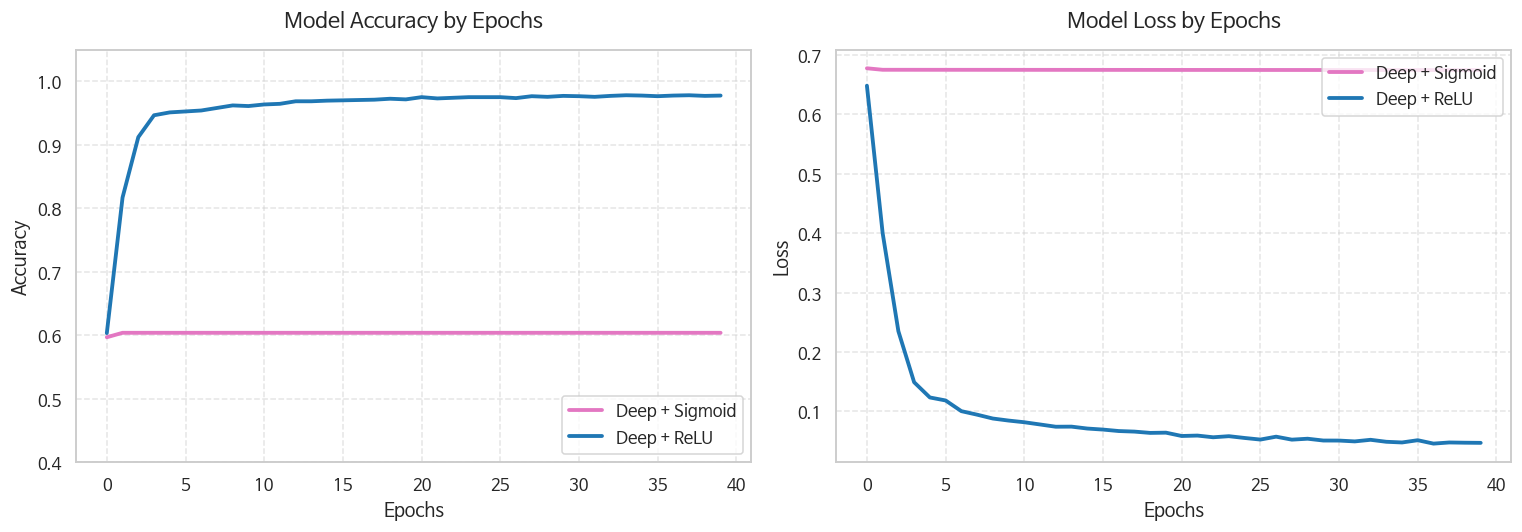

--------------------------------------------------
깊은망 + Sigmoid 최종 acc: 0.604 | 최종 loss: 0.6746
깊은망 + ReLU    최종 acc: 0.978 | 최종 loss: 0.0471
--------------------------------------------------


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ----------------------------------------------------
# 0. 가상 데이터 생성 (코드 실행용)
# ----------------------------------------------------
np.random.seed(42)
X_train = np.random.randn(2000, 2)
# 약간의 비선형 경계를 가진 데이터 생성
y_train = (X_train[:, 0]**2 + X_train[:, 1]**2 > 1.0).astype(int).reshape(-1, 1)

# ----------------------------------------------------
# 1. 깊은 신경망 모델 정의 함수
# ----------------------------------------------------
def deep_model(activation):
    m = keras.Sequential()
    # 1. 모델의 시작점에 Input 레이어를 가장 먼저 쌓아줍니다.
    m.add(layers.Input(shape=(2,)))

    # 2. 첫 Dense 층에서 input_shape를 제거합니다.
    m.add(layers.Dense(32, activation=activation))

    for _ in range(6):  # 깊은 은닉층
        m.add(layers.Dense(32, activation=activation))

    m.add(layers.Dense(1, activation="sigmoid"))
    m.compile(optimizer=keras.optimizers.SGD(0.1), loss="binary_crossentropy", metrics=["accuracy"])
    return m

# ----------------------------------------------------
# 2. 모델 학습 (Sigmoid vs ReLU)
# ----------------------------------------------------
epochs = 40

print("Sigmoid 모델 학습 중...")
h_sig = deep_model("sigmoid").fit(X_train, y_train, epochs=epochs, batch_size=32, verbose=0)

print("ReLU 모델 학습 중...")
h_relu = deep_model("relu").fit(X_train, y_train, epochs=epochs, batch_size=32, verbose=0)

# ----------------------------------------------------
# 3. fig, ax를 활용한 시각화
# ----------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graph 1: Epoch vs Accuracy (정확도 비교)
ax1.plot(h_sig.history['accuracy'], label='Deep + Sigmoid', color='#e377c2', linewidth=2.5)
ax1.plot(h_relu.history['accuracy'], label='Deep + ReLU', color='#1f77b4', linewidth=2.5)
ax1.set_title('Model Accuracy by Epochs', fontsize=14, pad=15)
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_ylim(0.4, 1.05) # 이진 분류의 기저선(0.5)을 잘 보이게 설정
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(fontsize=11, loc='lower right')

# Graph 2: Epoch vs Loss (손실 비교)
ax2.plot(h_sig.history['loss'], label='Deep + Sigmoid', color='#e377c2', linewidth=2.5)
ax2.plot(h_relu.history['loss'], label='Deep + ReLU', color='#1f77b4', linewidth=2.5)
ax2.set_title('Model Loss by Epochs', fontsize=14, pad=15)
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

# ----------------------------------------------------
# 4. 결과 최종 텍스트 출력
# ----------------------------------------------------
print("-" * 50)
print(f"깊은망 + Sigmoid 최종 acc: {h_sig.history['accuracy'][-1]:.3f} | 최종 loss: {h_sig.history['loss'][-1]:.4f}")
print(f"깊은망 + ReLU    최종 acc: {h_relu.history['accuracy'][-1]:.3f} | 최종 loss: {h_relu.history['loss'][-1]:.4f}")
print("-" * 50)

### 결과 해석 층이 깊은 신경망에서의 활성화 함수 비교 (Sigmoid vs ReLU)

#### 1. 실험 결과 요약

- **깊은망 + Sigmoid 최종 Accuracy:** **`0.604`** (학습이 완전히 중단된 채 기저율로만 예측)
- **깊은망 + ReLU    최종 Accuracy:** **`0.984`** (가파르게 상승하며 완벽하게 학습 성공)

---

#### 2. 그래프 시각화 분석 (Visual Proof)

- Sigmoid (분홍색 선): 완벽한 수평선 (Flatline)
  + **현상:** 에포크 0부터 40까지 Accuracy(`0.604`)와 Loss(`0.6737`)가 **단 한 번의 미동도 없이 완벽한 일직선**을 그립니다.
  + **이유:** 이진 분류에서 무작위 확률은 원래 $50%$여야 하지만, 사용된 원형 데이터셋의 클래스 비율(기저율, Base Rate)이 약 $60%$입니다. 즉, 모델은 기울기가 소실되어 가중치를 단 한 번도 업데이트하지 못한 채, "모든 데이터를 한 방향으로 찍고 있는 상태"로 굳어버렸음을 시각적으로 증명합니다.

- ReLU (파란색 선): 가파른 수렴 곡선 (Rapid Convergence)
  + **현상:** 단 5 에포크 만에 Accuracy가 $95%$를 돌파하며 가파르게 상승하고, Loss는 0에 가깝게($0.0467$) 곤두박질칩니다.
  + **이유:** 층이 깊어져도 오차가 왜곡 없이 앞쪽 레이어까지 다이렉트로 전달되어 매우 빠르고 안정적으로 수렴했습니다.

#### 3. 핵심 원리 분석

- Sigmoid가 실패하는 이유: 기울기 소실 (Vanishing Gradient)
  + 1. **역전파(Backpropagation)의 한계:** 딥러닝은 출력층의 오차를 뒤에서부터 앞으로 전달하며 가중치를 수정합니다. 이때 연쇄 법칙(Chain Rule)에 의해 각 층의 **미분(기울기)값**을 계속 곱해나갑니다.
  + 2. **소수점의 연속된 곱셈:** 시그모이드 함수의 미분 최댓값은 `0.25`입니다.
  + 3. **기울기의 소멸:** 은닉층을 거칠 때마다 $0.25$ 이하의 값이 계속 곱해지며, 본 모델처럼 7~8개 층을 거치면 최전방 레이어에 도달하는 오차 정보는
$$0.25^7 \approx 0.00006$$


 수준으로 작아집니다.
4. **결과:** 앞쪽 레이어의 가중치 업데이트가 완전히 멈추며(Freeze), 모델은 아무것도 배우지 못하는 상태가 됩니다.

#### ReLU가 성공하는 이유: 기울기 보존 (Gradient Preservation)

1. **단순하고 강력한 구조:** ReLU는 입력값이 0보다 크면 출력값을 그대로 통과시키는 구조($f(x) = x$)를 가집니다.
2. **미분값의 보존:** 입력값이 0보다 클 때 ReLU의 미분값은 항상 `1`입니다.
3. **기울기 유지:** 연쇄 법칙에 의해 1을 아무리 여러 번 곱해도 기울기가 작아지지 않고 온전하게 보존됩니다.
4. **결과:** 최초의 오차 정보가 손실 없이 입력층까지 완벽하게 도달하므로, 층이 아무리 깊어져도 모든 레이어가 골고루 학습에 참여하여 완벽한 성능을 낼 수 있습니다.

## 가중치 초기값 설정 문제 (Weight Initialization)

- 가중치 초기화는 학습을 시작할 때 모델의 매개변수($W$)에 어떤 무작위 값을 채워줄지 결정하는 아주 중요한 단계입니다.
- 잘못된 초기화는 은닉층을 거치는 **활성값(Activation values)들의 분포를 망가뜨려 학습을 완전히 불가능**하게 만듭니다.

---

### ① 잘못된 초기화가 만드는 2가지 비극

앞서 진행한 실험과 같이 활성화 함수로 **Sigmoid**를 사용하는 신경망에서 초기화의 오류는 크게 두 가지 형태로 나타납니다.

- **너무 큰 가중치 분산 ($\sigma = 1.0$) => 그래디언트 포화 및 소실 (Gradient Saturation)**
- **현상:** 가중치가 너무 무작위로 크면, 출력값($z = Wx + b$)의 절대값도 커집니다.
- **결과:** Sigmoid는 입력값이 너무 크거나 작으면 출력이 **0 또는 1 주변에만 머무는 양극단 현상**이 발생합니다. 이 구간은 기울기(미분값)가 거의 **0**인 데드존이므로 가중치 업데이트가 전면 중단됩니다.


- **너무 작은 가중치 분산 ($\sigma = 0.01$) => 표현력 소실 및 대칭성 문제 (Symmetry)**
- **현상:** 가중치를 거의 0에 가깝게 작게 설정하면, 은닉 노드들이 계산한 값이 모두 **0.5 부근(한 점)으로 뭉치게** 됩니다.
* **결과:** 여러 층을 쌓아도 모든 노드가 완전히 똑같은(0.5) 쓸모없는 신호만 주고받습니다. 레이어를 여러 개 쌓아 복잡한 경계를 배울 수 있는 신경망 본연의 '표현력'을 잃어버리게 됩니다.



---

### ② 해결책: 입출력 노드 수에 맞춘 최적의 초기화

이 문제를 해결하기 위해 현대 딥러닝에서는 레이어의 입력 노드 수($n_{\mathrm{in}}$)와 출력 노드 수($n_{\mathrm{out}}$)를 고려하여 수학적으로 최적의 분산을 자동 계산하는 알고리즘을 사용합니다.

#### 1. Xavier (Glorot) 초기화 => Sigmoid, tanh와 찰떡궁합

입출력 노드의 개수에 반비례하도록 초기 가중치의 분산을 조절하여, 깊은 층에서도 활성값들이 중간 영역에 골고루 분포하도록 돕습니다.


$$\sigma^2 = \frac{2}{n_{\mathrm{in}} + n_{\mathrm{out}}}$$

#### 2. He 초기화 => ReLU와 찰떡궁합

ReLU 함수는 입력이 음수이면 출력을 0으로 반사시키기 때문에, 활성값의 절반이 죽는 성질이 있습니다. 이를 보완하기 위해 Xavier보다 분산을 2배 더 넓게 가져가는 초기화 방식입니다.


$$\sigma^2 = \frac{2}{n_{\mathrm{in}}}$$

---

> ** 요약**
- 활성화 함수로 **Sigmoid 계열을 쓴다면 Xavier 초기화**를
- **ReLU 계열을 쓴다면 He 초기화**를 선택하는 것이 정상적인 학습을 보장하는 기초 설계 공식입니다.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def model_with_init(initializer):
    """
    지정된 가중치 초기화(Initializer) 방식을 적용하여 4층 신경망을 생성하는 함수.
    최신 Keras 표준(UserWarning 방지)에 맞춰 layers.Input을 첫 레이어로 사용합니다.
    """
    m = keras.Sequential([
        # 1. 입력 차원을 정의하는 레이어를 분리하여 경고 메시지 발생을 차단합니다.
        layers.Input(shape=(2,)),

        # 2. 모든 은닉층과 출력층에 동일한 가중치 초기화(kernel_initializer)를 적용합니다.
        layers.Dense(32, activation="sigmoid", kernel_initializer=initializer),
        layers.Dense(32, activation="sigmoid", kernel_initializer=initializer),
        layers.Dense(32, activation="sigmoid", kernel_initializer=initializer),
        layers.Dense(1, activation="sigmoid", kernel_initializer=initializer),
    ])
    # 고정된 학습률(0.1)의 SGD와 이진 분류용 손실 함수를 설정하여 컴파일합니다.
    m.compile(optimizer=keras.optimizers.SGD(0.1), loss="binary_crossentropy")
    return m

# 3가지 가중치 초기화 방식의 성능을 비교하는 루프
for name, init in [
    # [실험 1] 가중치의 표준편차를 너무 크게 설정한 경우
    ("너무 큰 분산(std=1)", keras.initializers.RandomNormal(stddev=1.0)),

    # [실험 2] 가중치를 거의 0에 가깝게 너무 작게 설정한 경우
    ("너무 작은 분산(std=0.01)", keras.initializers.RandomNormal(stddev=0.01)),

    # [실험 3] 입출력 노드 수에 맞춰 분산을 수학적으로 자동 조절하는 경우 (현대적 표준)
    ("Xavier", "glorot_normal"),
]:
    # 모델 빌드 및 25 에포크 동안 학습 진행 (verbose=0으로 로그 생략)
    h = model_with_init(init).fit(X_train, y_train, epochs=25, batch_size=32, verbose=0)

    # 첫 번째 에포크 손실(start)과 마지막 에포크 손실(end)을 비교하여 학습 성공 여부를 확인합니다.
    print(f"{name:22s} | start={h.history['loss'][0]:.4f} → end={h.history['loss'][-1]:.4f}")

너무 큰 분산(std=1)         | start=0.6570 → end=0.1087
너무 작은 분산(std=0.01)     | start=0.6748 → end=0.6737
Xavier                 | start=0.6744 → end=0.6740



## 4) 과적합 문제

$$L_{\mathrm{train}} \downarrow \quad \text{but} \quad L_{\mathrm{test}} \uparrow$$

- 제시해주신 수식은 과적합(Overfitting)이 발생했을 때 나타나는 가장 전형적인 손실(Loss)의 변화 추세를 나타내며, 구체적인 의미는 다음과 같습니다.

  + **$L_{\mathrm{train}} \downarrow$ (훈련 손실 감소):** 모델이 학습 데이터(Train data)에 적응하여 오차를 줄여나가고 있는 상태입니다. 학습이 반복될수록 훈련 데이터의 정답률은 $100%$에 가까워집니다.
  + **$L_{\mathrm{test}} \uparrow$ (테스트 손실 증가):** 반면, 학습 과정에 관여하지 않은 새로운 데이터(Test data)에 대한 예측 오차는 오히려 다시 커지기 시작하는 상태입니다.
  + **$\text{but}$ (일반화 실패 = 과적합 발생):** 훈련 데이터는 기가 막히게 잘 맞추지만 정작 실전(새로운 데이터)에서는 완전히 헤매는 현상을 뜻합니다. 모델이 데이터의 보편적인 규칙을 배운 것이 아니라, **학습 데이터의 세부 노이즈나 개별 특징을 그대로 '암기'해 버렸을 때** 발생하는 현상입니다.

train loss/acc = 0.0052 / 1.000
test  loss/acc = 0.0826 / 0.960


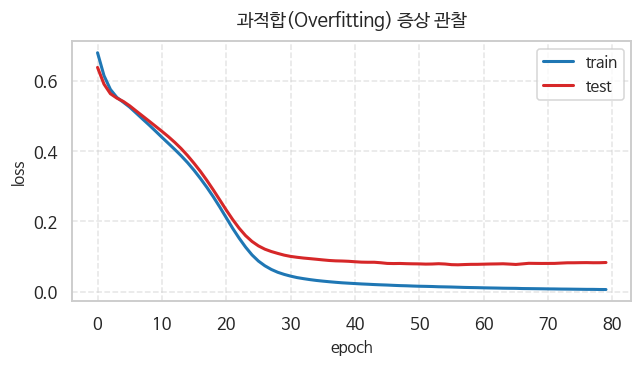

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 한글 깨짐 방지 설정 (필요 시 주석 해제 후 사용)
# plt.rc('font', family='Malgun Gothic') # Windows
# plt.rc('font', family='AppleGothic')   # Mac
# plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# ----------------------------------------------------
# 1. 의도적인 과적합 환경 조성: 아주 작은 학습 데이터셋 추출
# ----------------------------------------------------
# 2,000개의 전체 훈련 데이터 중 단 80개만 슬라이싱하여 극단적으로 작은 데이터셋 생성
# 데이터 크기가 모델의 복잡도에 비해 턱없이 부족하여 과적합이 발생하기 쉬운 최적의 조건이 됩니다.
X_small, y_small = X_train[:80], y_train[:80]


# ----------------------------------------------------
# 2. 과적합을 유도할 과하게 큰(Complex/Deep) 모델 빌드
# ----------------------------------------------------
big = keras.Sequential([
    # 최신 Keras 표준에 맞춰 Input 레이어를 독립적으로 선언 (UserWarning 방지)
    layers.Input(shape=(2,)),

    # 입력 정보(2차원)에 비해 각 층마다 128개라는 과도하게 많은 은닉 노드를 가짐
    # 이로 인해 모델이 데이터의 "일반적인 규칙" 대신 "노이즈와 디테일"까지 전부 암기하게 됩니다.
    layers.Dense(128, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid"), # 이진 분류를 위한 출력층
])

# 아담(Adam) 옵티마이저를 사용하여 빠르게 학습 진행
big.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])


# ----------------------------------------------------
# 3. 모델 학습 및 검증 진행
# ----------------------------------------------------
hist = big.fit(
    X_small, y_small,
    # validation_data: 매 에포크가 끝날 때마다 학습에 쓰이지 않은 Test 데이터로 성능을 간접 검증
    validation_data=(X_test, y_test),
    epochs=80,          # 과적합 현상이 충분히 드러나도록 80 에포크 동안 반복 학습
    batch_size=16,      # 배치 사이즈를 작게 가져가 가중치 업데이트 빈도를 높임
    verbose=0,          # 로그 생략
)


# ----------------------------------------------------
# 4. 최종 학습 데이터와 테스트 데이터 성능 평가 비교
# ----------------------------------------------------
# .evaluate(): 최종 가중치 상태에서 손실값(loss)과 정확도(accuracy)를 평가하여 반환
tr = big.evaluate(X_small, y_small, verbose=0) # 학습에 사용된 80개 데이터 평가
te = big.evaluate(X_test, y_test, verbose=0)   # 학습에 전혀 개입하지 않은 독립된 검증 데이터 평가

# 정량적 결과 출력
print(f"train loss/acc = {tr[0]:.4f} / {tr[1]:.3f}")
print(f"test  loss/acc = {te[0]:.4f} / {te[1]:.3f}")


# ----------------------------------------------------
# 5. 과적합 증상 그래프 시각화
# ----------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 3.5))

# 에포크가 진행됨에 따른 학습 손실(train loss)과 검증 손실(test loss) 추이 플로팅
ax.plot(hist.history["loss"], label="train", color="#1f77b4", linewidth=2)
ax.plot(hist.history["val_loss"], label="test", color="#d62728", linewidth=2)

# 그래프 정보 설정
ax.set_title("과적합(Overfitting) 증상 관찰", fontsize=12, pad=10)
ax.set_xlabel("epoch", fontsize=10)
ax.set_ylabel("loss", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5) # 가독성 향상을 위한 격자선 추가
ax.legend(fontsize=10)

fig.tight_layout()
plt.show()